# Exploración Inicial de Datos (EDA) - Predicción de Insuficiencia Cardíaca
**Autor:** Isabel
**Algoritmo asignado para el modelo final:** K-Nearest Neighbors (K-NN)

## 📝 Descripción
En este notebook realizaremos el análisis exploratorio de datos (EDA) para entender las variables del dataset `heart.csv`. 
[cite_start]El objetivo es responder a las preguntas de investigación planteadas por el equipo.

--- Balance de Clases ---
HeartDisease
1    508
0    410
Name: count, dtype: int64

--- Porcentaje ---
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


C:\Users\Coder\AppData\Local\Temp\ipykernel_13020\269236901.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df_eda, palette='viridis')


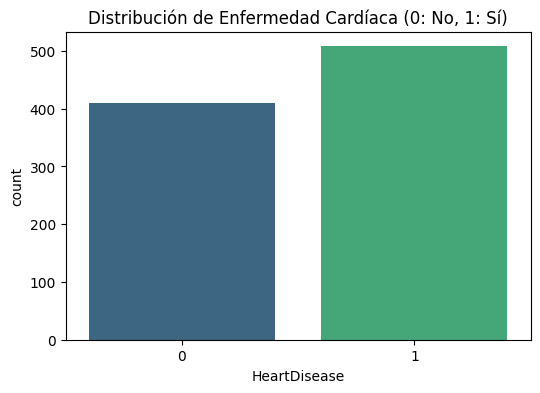

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de datos
# Usamos ruta relativa para no modificar el original en /data
df = pd.read_csv('../data/heart.csv')
df_eda = df.copy()

# 2. Exploración General - Balance de clases
# Respondemos: ¿Cuántos pacientes hay con y sin enfermedad cardíaca?
print("--- Balance de Clases ---")
print(df_eda['HeartDisease'].value_counts())
print("\n--- Porcentaje ---")
print(df_eda['HeartDisease'].value_counts(normalize=True) * 100)

# 3. Visualización
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df_eda, palette='viridis')
plt.title('Distribución de Enfermedad Cardíaca (0: No, 1: Sí)')
plt.show()

# Mostramos las primeras filas para confirmar que todo está correcto
df_eda.head()

--- Estadísticas de Edad ---
count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64


C:\Users\Coder\AppData\Local\Temp\ipykernel_13020\1111140300.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df_eda, palette='magma')


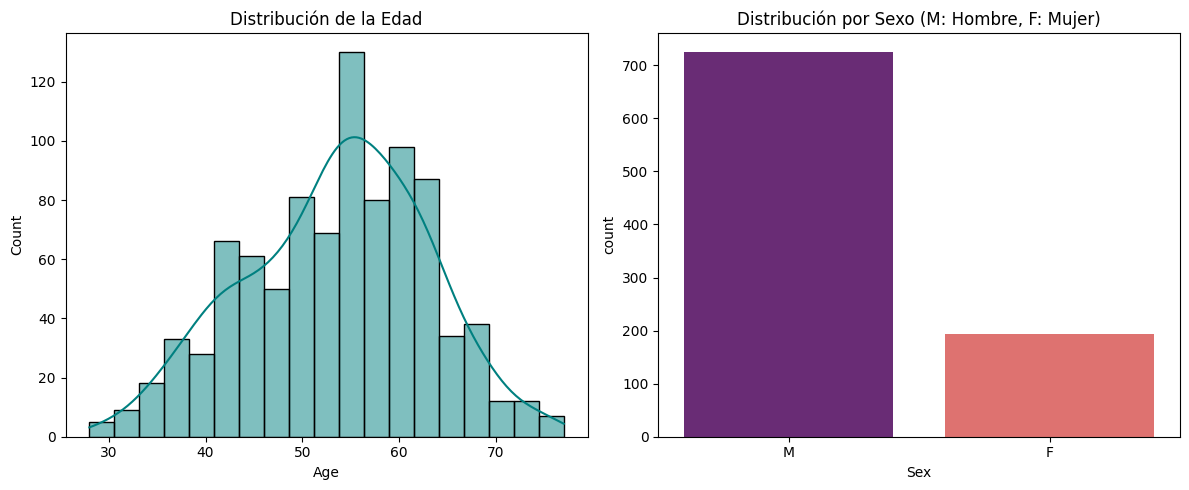

In [2]:
# 3.1 Características demográficas
# Analizamos la distribución de Edad y Sexo de los pacientes

print("--- Estadísticas de Edad ---")
print(df_eda['Age'].describe())

# Visualizamos la distribución de edad y el sexo
plt.figure(figsize=(12, 5))

# Histograma de edad
plt.subplot(1, 2, 1)
sns.histplot(df_eda['Age'], kde=True, color='teal')
plt.title('Distribución de la Edad')

# Gráfico de barras por Sexo
plt.subplot(1, 2, 2)
sns.countplot(x='Sex', data=df_eda, palette='magma')
plt.title('Distribución por Sexo (M: Hombre, F: Mujer)')

plt.tight_layout()
plt.show()

In [3]:
# 3.1 Datos faltantes e inconsistencias
# Comprobamos si hay huecos en la información

print("--- Datos faltantes por columna ---")
print(df_eda.isnull().sum())

print("\n--- Tipos de datos ---")
print(df_eda.dtypes)

# Resumen estadístico para ver si hay valores imposibles (ej. Colesterol = 0)
df_eda.describe()

--- Datos faltantes por columna ---
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

--- Tipos de datos ---
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Pacientes con RestingBP igual a 0: 1
Pacientes con Cholesterol igual a 0: 172


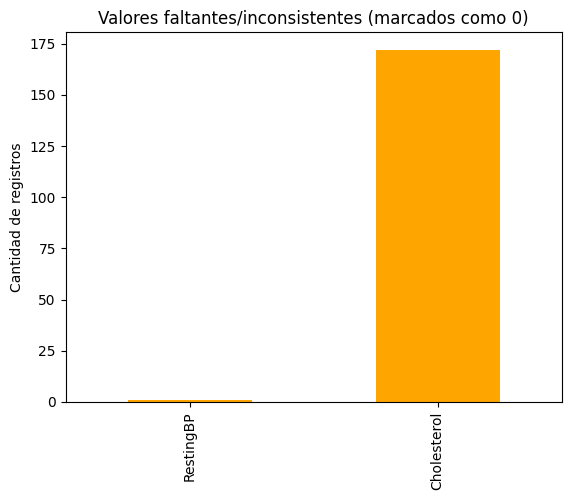

In [5]:
# 3.1 Visualización de inconsistencias
# Vamos a ver cuántos pacientes tienen valores de 0 en Colesterol y Presión

cols_con_ceros = ['RestingBP', 'Cholesterol']
for col in cols_con_ceros:
    cantidad_ceros = (df_eda[col] == 0).sum()
    print(f"Pacientes con {col} igual a 0: {cantidad_ceros}")

# Creamos un gráfico sencillo para el informe
df_eda[cols_con_ceros].replace(0, pd.NA).isnull().sum().plot(kind='bar', color='orange')
plt.title('Valores faltantes/inconsistentes (marcados como 0)')
plt.ylabel('Cantidad de registros')
plt.show()

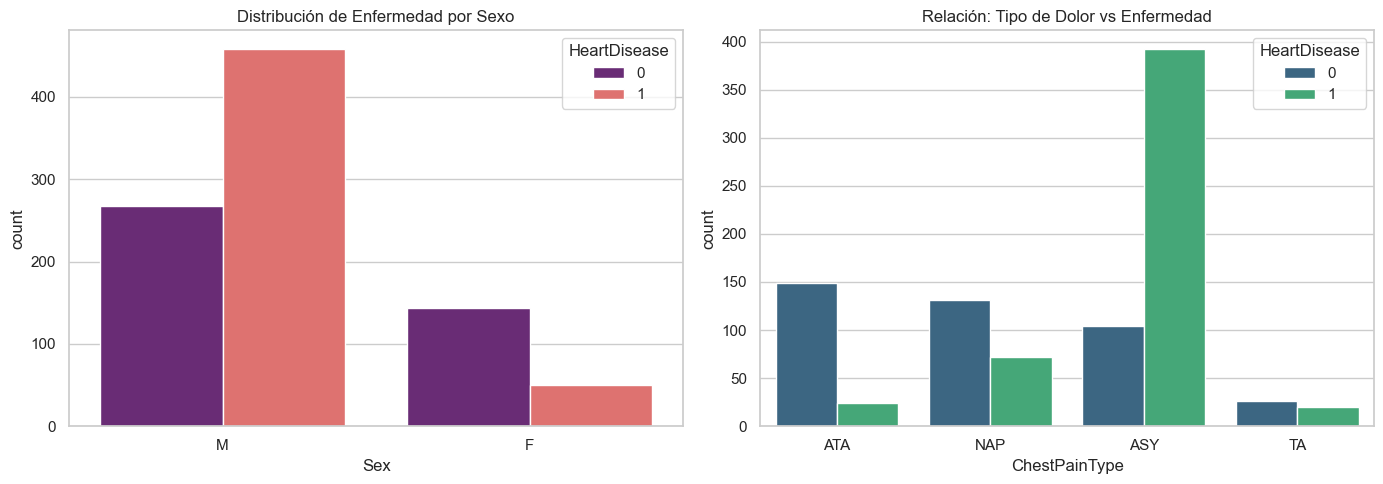

--- Proporción de enfermedad por sexo ---
Sex
F    0.259067
M    0.631724
Name: HeartDisease, dtype: float64


In [7]:
# 3.2 Análisis de Variables Categóricas
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo para que sea profesional
sns.set_theme(style="whitegrid")

# Creamos una figura con dos gráficos: Sexo y Tipo de Dolor de Pecho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Relación Sexo y Enfermedad
sns.countplot(data=df_eda, x='Sex', hue='HeartDisease', ax=axes[0], palette='magma')
axes[0].set_title('Distribución de Enfermedad por Sexo')

# Gráfico 2: Relación Tipo de Dolor y Enfermedad
sns.countplot(data=df_eda, x='ChestPainType', hue='HeartDisease', ax=axes[1], palette='viridis')
axes[1].set_title('Relación: Tipo de Dolor vs Enfermedad')

plt.tight_layout()
plt.show()

# Mostramos los porcentajes reales para el informe
print("--- Proporción de enfermedad por sexo ---")
print(df_eda.groupby('Sex')['HeartDisease'].mean())

C:\Users\Coder\AppData\Local\Temp\ipykernel_13020\2969458721.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='HeartDisease', y='RestingBP', ax=axes[1], palette='Set1')
C:\Users\Coder\AppData\Local\Temp\ipykernel_13020\2969458721.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='HeartDisease', y='MaxHR', ax=axes[2], palette='Set3')


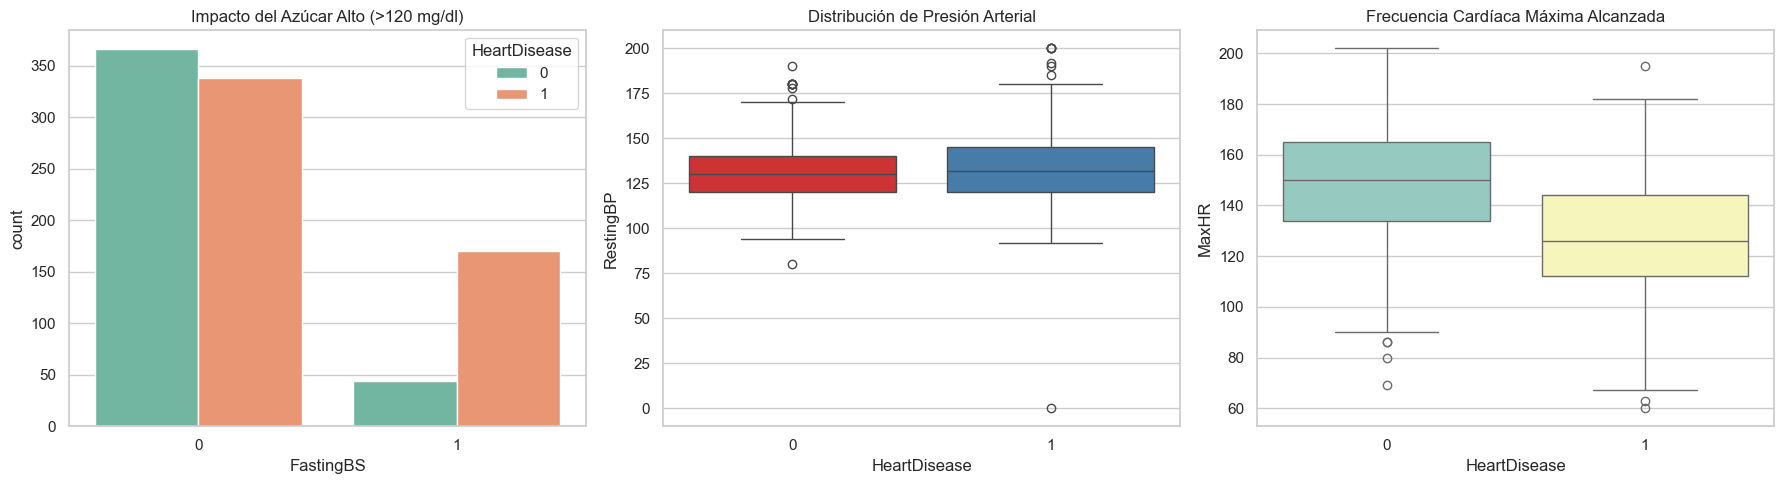

In [8]:
# 3.2.3 Análisis de Azúcar, Presión y Frecuencia Cardíaca
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Azúcar en sangre (FastingBS) - Variable categórica (0 o 1)
sns.countplot(data=df_eda, x='FastingBS', hue='HeartDisease', ax=axes[0], palette='Set2')
axes[0].set_title('Impacto del Azúcar Alto (>120 mg/dl)')

# Presión arterial (RestingBP) - Variable numérica
sns.boxplot(data=df_eda, x='HeartDisease', y='RestingBP', ax=axes[1], palette='Set1')
axes[1].set_title('Distribución de Presión Arterial')

# Frecuencia cardíaca máxima (MaxHR) - Variable numérica
sns.boxplot(data=df_eda, x='HeartDisease', y='MaxHR', ax=axes[2], palette='Set3')
axes[2].set_title('Frecuencia Cardíaca Máxima Alcanzada')

plt.tight_layout()
plt.show()